# Contextual Scouting — UEFA Euro 2024

## Hypothesis 1 (Space Control and Value)

A spatial-tactical scouting platform built on StatsBomb 360 open data for **UEFA Euro 2024** (51 matches).

The pipeline turns event-level data into a per-player tactical fingerprint built around four composite indices:

- **PROGRESSION**, forward play volume (line-breakers, hull penetrations).
- **DANGEROUSNESS**, threat creation.
- **RECEPTION**, between-the-lines play and tight-space technique.
- **GRAVITY**, spatial pull on the opposing defense.

All percentile comparisons are made **within macro-role** (CB / FB / MID / CAM / WIDE / FW).
## Pipeline 

```
StatsBomb events + 360 frames
        │
        ▼
  Player totals          ──►  Euro2024_Player_Totals_Distances_Roles.xlsx
        │
        ▼
  Hull Metrics Pipeline  ──►  hull_events_raw.csv
                              hull_zone_baselines.csv
                              hull_metrics_aggregated.csv
        │
        ▼
  Directional Gravity         (extends hull_metrics_aggregated.csv)
        │
        ▼
  EPV Pipeline           ──►  hull_events_with_epv.csv  (open play only)
        │
        ▼
  Line Breaker Pipeline  ──►  hull_events_lb.csv
        │
        ▼
  Player Aggregation     ──►  player_space_control_aggregated.csv
        │
        ▼
  Indices + Dashboard    ──►  player_space_control_indices.csv
                              4 prototype views (radars / leaderboards / archetypes)
```

## Conventions

- **Coordinates**: pitch in meters (105 × 68, UEFA standard). StatsBomb yard coordinates are converted via `X_SCALE = 105/120`, `Y_SCALE = 68/80`.
- **Open play**: the EPV step filters out corners, free kicks, throw-ins and kick-offs. Percentage rates downstream use the open-play subset (`passes_op`).
- **Leave-one-out gravity**: each player's gravity is measured against a baseline that **excludes** their own passes, so high-volume players aren't compared against themselves.
- **Within-role percentiles**: every radar axis is the player's percentile rank inside their macro-role.


## Player totals

Pulls every Euro 2024 match from StatsBomb Open Data and builds a per-player tournament-level table.

**Columns produced**:

- *Identity*: team, player_id, player, primary_role (mode of tactical positions across matches), minutes_played.
- *Counts*: total_touches, passes (attempted / successful / failed / under pressure), through_balls, switches_of_play, crosses, assists, key_passes, carries, shots, shots_on_target, goals, dribbles, ball_recoveries, interceptions, tackles_won, aerials_won, clearances, blocks, fouls, dispossessed, miscontrols.
- *Distance*: total and average pass distance for all / successful / failed passes.
- *Derived*: pass completion %.

**Filter**: keep players with at least 90 minutes played in the tournament.

**Output**: `Euro2024_Player_Totals_Distances_Roles.csv` and `.xlsx`. The Excel file is the **whitelist** consumed by the Hull Metrics Pipeline.


In [1]:
# Setup: ensure project root is on sys.path so `from src...` works
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
from src.player_totals import main
main()


Phase 1: Fetching all UEFA Euro 2024 matches...
Found 51 matches. Starting the Match-by-Match processing...

Processing match 1/51 (ID: 3942819)...
Processing match 2/51 (ID: 3943043)...
Processing match 3/51 (ID: 3942752)...
Processing match 4/51 (ID: 3942382)...
Processing match 5/51 (ID: 3942349)...
Processing match 6/51 (ID: 3930180)...
Processing match 7/51 (ID: 3930171)...
Processing match 8/51 (ID: 3942227)...
Processing match 9/51 (ID: 3942226)...
Processing match 10/51 (ID: 3938645)...
Processing match 11/51 (ID: 3930184)...
Processing match 12/51 (ID: 3941022)...
Processing match 13/51 (ID: 3941021)...
Processing match 14/51 (ID: 3941020)...
Processing match 15/51 (ID: 3941019)...
Processing match 16/51 (ID: 3941018)...
Processing match 17/51 (ID: 3941017)...
Processing match 18/51 (ID: 3930182)...
Processing match 19/51 (ID: 3930179)...
Processing match 20/51 (ID: 3940983)...
Processing match 21/51 (ID: 3940878)...
Processing match 22/51 (ID: 3930177)...
Processing match 23/

,team,player_id,player,primary_role,minutes_played,total_touches,passes_attempted,passes_successful,passes_failed,pass_completion_pct,...,ball_recoveries,interceptions,tackles_won,aerials_won,clearances,blocks,fouls_committed,fouls_won,dispossessed,miscontrols
126,England,3943,Declan Rice,Left Defensive Midfield,691,1671,536,488,48,91.0,...,40,8,3,0,9,11,8,5,7,5
119,England,3244,John Stones,Right Center Back,686,1624,558,523,35,93.7,...,17,0,1,0,24,7,5,4,0,1
118,England,3205,Kyle Walker,Right Back,690,1603,562,497,65,88.4,...,22,6,2,0,9,12,5,3,2,3
183,Germany,5574,Toni Kroos,Left Defensive Midfield,485,1546,545,489,56,89.7,...,12,6,1,0,3,4,7,7,1,0
135,England,30714,Jude Bellingham,Center Attacking Midfield,668,1500,374,317,57,84.8,...,32,5,6,0,5,15,9,19,15,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463,Turkey,30442,Altay Bayındır,Goalkeeper,94,103,35,28,7,80.0,...,5,0,0,0,0,0,0,0,0,0
387,Slovenia,11416,Jon Gorenc Stankovič,Left Defensive Midfield,92,86,22,16,6,72.7,...,3,1,0,0,3,3,1,1,0,0
90,Czech Republic,29484,Jan Kuchta,Left Center Forward,98,85,13,9,4,69.2,...,3,0,1,0,3,1,1,0,0,2
273,Poland,11508,Łukasz Skorupski,Goalkeeper,92,75,29,23,6,79.3,...,3,0,0,0,0,0,0,0,0,0


## Hull Metrics Pipeline

The core spatial pipeline. For every Pass with a 360 freeze frame, computes geometric features over the convex hull of visible opponents and aggregates them per player.

**Inputs**: StatsBomb events + 360 frames + `Euro2024_Player_Totals_Distances_Roles.xlsx`.

**Outputs**:

- `hull_events_raw.csv`, one row per analysed pass (event-level features).
- `hull_zone_baselines.csv`, tournament-level zonal baselines (transparency).
- `hull_metrics_aggregated.csv`, one row per player.

**Metrics**:

- **Between Lines %**, how often the player is inside the opponent hull when playing the ball.
- **Pressure Resistance %**, completion rate under pressure (≥ 2 opponents within 2.5 m).
- **Hull Exit %**, clean ball-exits from inside the block.
- **Hull Penetration %**, passes from outside the block ending inside.
- **Defensive Gravity** (hull / proximity / composite), how much the defense compacts when the player has the ball, measured against the team's same-zone leave-one-out baseline (match-level preferred, tournament-level fallback).
- Per-90 volumes for between-lines actions, hull exits, hull penetrations.

**Parameters**: `PRESSURE_RADIUS = 2.5 m`, `PRESSURE_MIN = 2`, `K_NEAREST = 4`, zone grid `12 × 8`, `MIN_BASELINE_FRAMES = 10`.

This cell downloads every match and freeze frame on first run, and is the upstream of every later cell.


In [3]:
from src.hull_metrics import main
main()


STEP 0 - Loading player list from totals file
Target players: 357  (MIN_MINUTES=0)

STEP 1 - Fetching Euro 2024 match list
Matches to process: 51

STEP 2 - Processing matches (events + 360 frames)
  [5/51] matches processed (10s)  pass rows: 4451  baseline rows: 4502
  [10/51] matches processed (33s)  pass rows: 9240  baseline rows: 9496
  [15/51] matches processed (42s)  pass rows: 13329  baseline rows: 13729
  [20/51] matches processed (51s)  pass rows: 18004  baseline rows: 18726
  [25/51] matches processed (61s)  pass rows: 22238  baseline rows: 23139
  [30/51] matches processed (71s)  pass rows: 26753  baseline rows: 27775
  [35/51] matches processed (81s)  pass rows: 30672  baseline rows: 32015
  [40/51] matches processed (89s)  pass rows: 34701  baseline rows: 36267
  [45/51] matches processed (99s)  pass rows: 38677  baseline rows: 40424
  [50/51] matches processed (108s)  pass rows: 42858  baseline rows: 44788
  [51/51] matches processed (109s)  pass rows: 43628  baseline rows

,player,team,primary_role,minutes_played,passes_total,passes_analysed,coverage_pct,between_lines_pct,between_lines_n,pressure_resistance_pct,...,hull_exit_n,hull_penetration_pct,hull_penetration_n,gravity_hull_pct,gravity_proximity_pct,gravity_composite_pct,gravity_n,between_lines_per90,successful_hull_exits_per90,successful_hull_penetrations_per90
0,Declan Rice,England,Left Defensive Midfield,691,536,481,89.738806,26.611227,128,84.615385,...,128,13.031161,353,2.904906,10.182064,6.543485,474,16.671491,8.986975,5.991317
1,John Stones,England,Right Center Back,686,558,498,89.247312,4.016064,20,0.000000,...,20,12.343096,478,2.529611,-20.091069,-8.780729,470,2.623907,1.311953,7.740525
2,Kyle Walker,England,Right Back,690,562,443,78.825623,3.611738,16,50.000000,...,16,13.114754,427,0.089858,-20.230218,-10.070180,414,2.086957,0.782609,7.304348
3,Toni Kroos,Germany,Left Defensive Midfield,485,545,475,87.155963,18.947368,90,75.000000,...,90,28.831169,385,-1.007773,-3.949846,-2.478809,447,16.701031,10.206186,20.597938
4,Jude Bellingham,England,Center Attacking Midfield,668,374,331,88.502674,39.577039,131,60.714286,...,131,13.500000,200,-2.423348,18.366470,7.971561,320,17.649701,10.913174,3.637725
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,Altay Bayındır,Turkey,Goalkeeper,94,35,29,82.857143,0.000000,0,NaN,...,0,3.448276,29,-22.112801,-10.362829,-16.237815,27,0.000000,0.000000,0.957447
353,Jon Gorenc Stankovič,Slovenia,Left Defensive Midfield,92,22,21,95.454545,76.190476,16,NaN,...,16,0.000000,5,14.414560,22.433255,18.423907,19,15.652174,5.869565,0.000000
354,Jan Kuchta,Czech Republic,Left Center Forward,98,13,12,92.307692,58.333333,7,NaN,...,7,0.000000,5,-31.150565,-8.585924,-19.868244,4,6.428571,2.755102,0.000000
355,Łukasz Skorupski,Poland,Goalkeeper,92,29,13,44.827586,0.000000,0,NaN,...,0,23.076923,13,-33.523011,-14.709491,-24.116251,8,0.000000,0.000000,2.934783


## Directional Gravity

Adds two columns to `hull_metrics_aggregated.csv`:

- **`gravity_directional_m`**, signed displacement (in meters) of the opponent centroid towards the player's position, vs. the leave-one-out baseline at the same `(match, zone)`. Positive values mean defenders collapse onto the player (high directional gravity); negative values mean defenders move away (the player structurally disrupts the block).
- **`gravity_directional_n`**, number of events with a usable LOO baseline (reliability flag).

The composite gravity (hull + proximity) measures **how compact** the defense is. Directional gravity measures **whether it shifts toward the player**, a conceptually distinct signal.

Opponent centroids are cached to `opp_centroids_cache.parquet` so re-runs are cheap.


In [4]:
from src.directional_gravity import main
main()


Hull events: 43,628   Matches: 51
Loading cached centroids -> /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Space_Control_and_Value/data/cache/opp_centroids_cache.parquet

DONE. gravity_directional_m added to: /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Space_Control_and_Value/data/hull_metrics_aggregated.csv

Top 10 by gravity_directional_m (min 100 baseline events):
              player        team  minutes_played  gravity_composite_pct  gravity_directional_m  gravity_directional_n
       Memphis Depay Netherlands             463               9.249962               6.189303                    104
Giorgi Kochorashvili     Georgia             373              16.844283               4.663939                    128
         Ondrej Duda    Slovakia             323              12.323078               4.613293                    147
  Mikel Merino Zazón       Spain             195               9.233911               3.733042                    111
     Piotr Zi

,player,team,primary_role,minutes_played,passes_total,passes_analysed,coverage_pct,between_lines_pct,between_lines_n,pressure_resistance_pct,...,hull_penetration_n,gravity_hull_pct,gravity_proximity_pct,gravity_composite_pct,gravity_n,between_lines_per90,successful_hull_exits_per90,successful_hull_penetrations_per90,gravity_directional_m,gravity_directional_n
0,Declan Rice,England,Left Defensive Midfield,691,536,481,89.738806,26.611227,128,84.615385,...,353,2.904906,10.182064,6.543485,474,16.671491,8.986975,5.991317,1.409412,451
1,John Stones,England,Right Center Back,686,558,498,89.247312,4.016064,20,0.000000,...,478,2.529611,-20.091069,-8.780729,470,2.623907,1.311953,7.740525,-3.056196,456
2,Kyle Walker,England,Right Back,690,562,443,78.825623,3.611738,16,50.000000,...,427,0.089858,-20.230218,-10.070180,414,2.086957,0.782609,7.304348,-1.467649,392
3,Toni Kroos,Germany,Left Defensive Midfield,485,545,475,87.155963,18.947368,90,75.000000,...,385,-1.007773,-3.949846,-2.478809,447,16.701031,10.206186,20.597938,-1.225729,418
4,Jude Bellingham,England,Center Attacking Midfield,668,374,331,88.502674,39.577039,131,60.714286,...,200,-2.423348,18.366470,7.971561,320,17.649701,10.913174,3.637725,2.312960,287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,Altay Bayındır,Turkey,Goalkeeper,94,35,29,82.857143,0.000000,0,NaN,...,29,-22.112801,-10.362829,-16.237815,27,0.000000,0.000000,0.957447,-4.207694,29
353,Jon Gorenc Stankovič,Slovenia,Left Defensive Midfield,92,22,21,95.454545,76.190476,16,NaN,...,5,14.414560,22.433255,18.423907,19,15.652174,5.869565,0.000000,5.902554,20
354,Jan Kuchta,Czech Republic,Left Center Forward,98,13,12,92.307692,58.333333,7,NaN,...,5,-31.150565,-8.585924,-19.868244,4,6.428571,2.755102,0.000000,10.153408,11
355,Łukasz Skorupski,Poland,Goalkeeper,92,29,13,44.827586,0.000000,0,NaN,...,13,-33.523011,-14.709491,-24.116251,8,0.000000,0.000000,2.934783,-3.863313,8


## EPV grid sanity-check

Visualises the EPV (Expected Possession Value) grid loaded from `EPV_grid.csv` (Friends-of-Tracking-Data) to confirm three things:

1. **Orientation**, values increase from defensive to attacking third (attack to the right).
2. **Dynamic range**, values near the opposing goal are 100 to 150 times larger than at midfield. A linear colormap collapses everything except the peak; three views (linear / log / power γ=0.4) make the structure visible.
3. **Mean by pitch third**, defensive < middle < attacking is the expected ordering.


EPV grid shape : (32, 50)  (rows=Y/width, cols=X/length)
  min  = 0.0041
  max  = 0.5714
  mean = 0.0264
  argmax at grid (row=15, col=49) -> pitch (x~104.0 m, y~32.9 m)
  ratio max/min = 139.4x  (-> linear scale flattens everything except the peak)


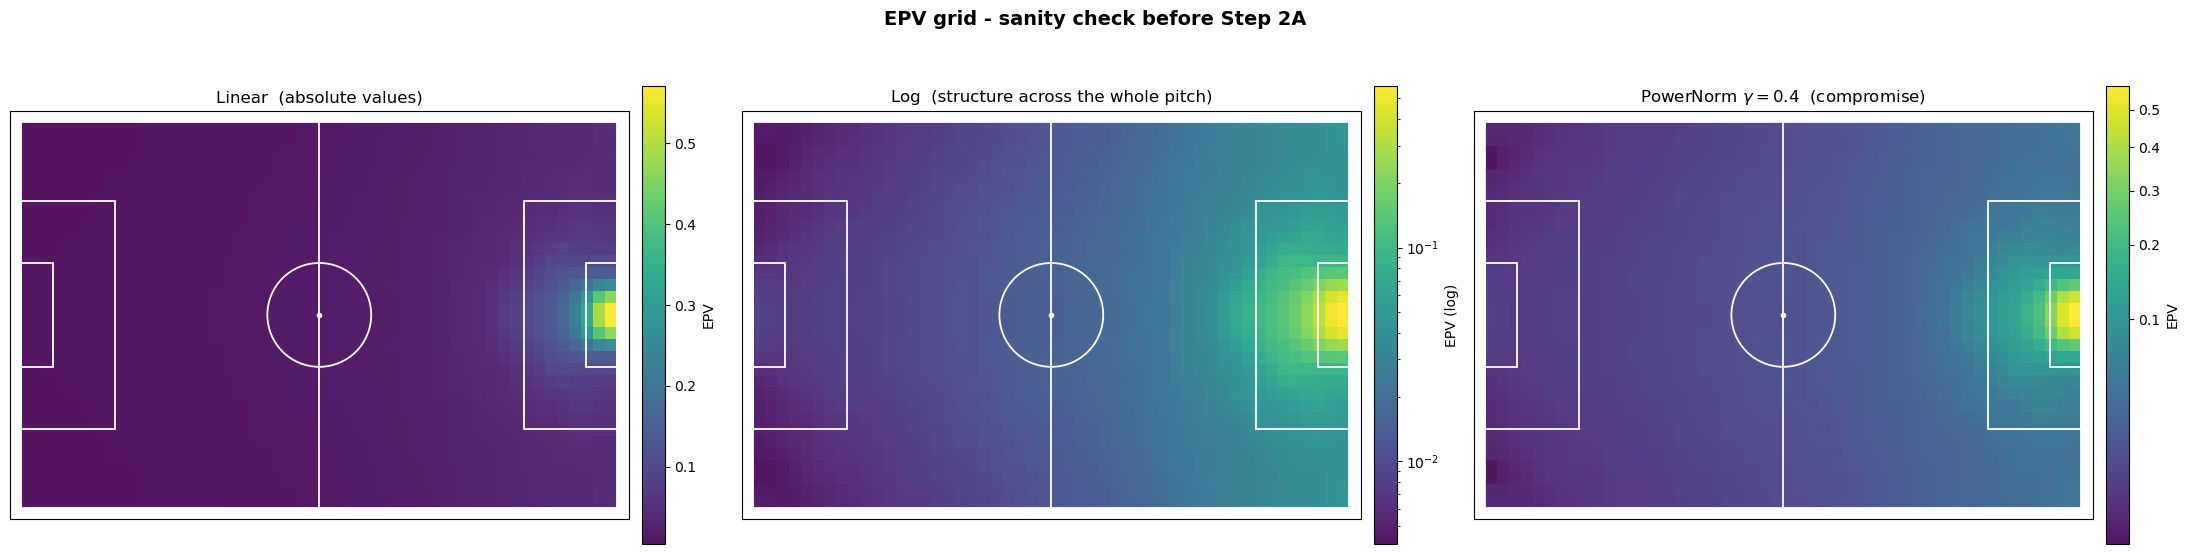

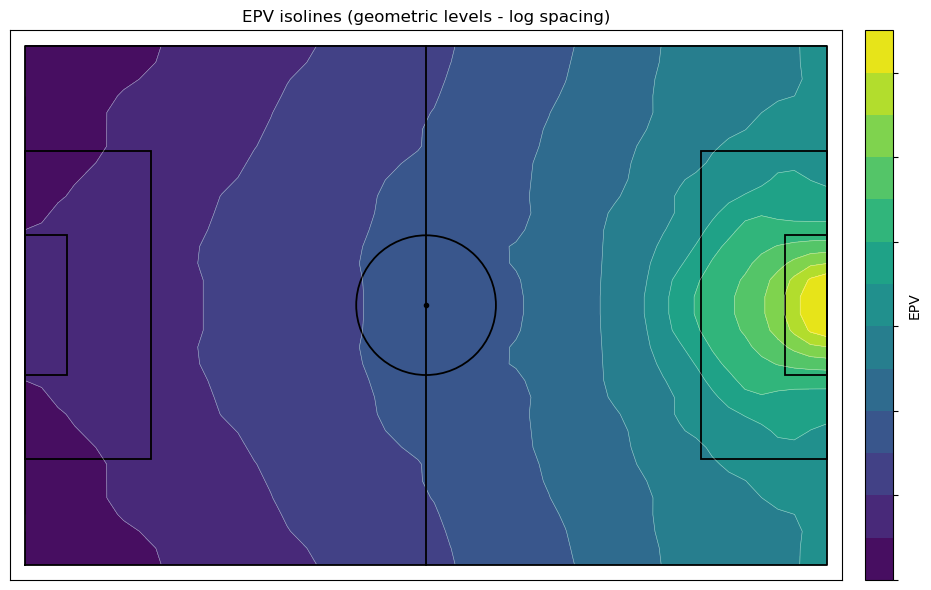


Orientation sanity check:
  left half  (defensive): mean EPV = 0.0087
  right half (attacking): mean EPV = 0.0441
  OK: grid is oriented correctly (attack to the right).

Mean EPV by pitch third:
  defensive third     : 0.0072  (max = 0.0103)
  middle third        : 0.0137  (max = 0.0211)
  attacking third     : 0.0572  (max = 0.5714)


In [5]:
from src.epv_pipeline import show_grid_diagnostic
show_grid_diagnostic()


## EPV pipeline (open-play filter)

Enriches `hull_events_raw.csv` with EPV features and **filters to open play only**.

**Steps**:

1. Load the EPV grid and define a bilinear interpolation lookup `epv_at(x, y)` in pitch meters.
2. Re-fetch every Pass event and keep only those where `pass_type` is NaN, i.e. open play (StatsBomb set-piece passes always carry a `pass_type` value).
3. Inner-join with `hull_events_raw.csv`, dropping every set-piece pass.
4. For each surviving pass, compute `epv_start`, `epv_end`, `epv_added` (= end − start) and a `geom_type` flag (Penetration / Exit / Inside circulation / Outside circulation) based on hull topology.

**Output**: `hull_events_with_epv.csv`, open-play passes with EPV features. 

In [6]:
from src.epv_pipeline import main
main()



STEP 1 - Loading EPV grid

STEP 3 - Re-fetching pass coordinates and filtering Open Play
  (automatically excludes Corners, Free Kicks, Throw-ins and Kick-offs)
  [10/51] matches processed... (1.1s)
  [20/51] matches processed... (2.2s)
  [30/51] matches processed... (3.3s)
  [40/51] matches processed... (4.4s)
  [50/51] matches processed... (5.5s)
  [51/51] matches processed... (5.6s)

STEP 4 - Joining coordinates and computing EPV features
  Removed 5462 set-piece events.

DONE. File saved at: /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Space_Control_and_Value/data/hull_events_with_epv.csv


,match_id,event_id,player,team,minute,second,position,hull_area_m2,n_opponents_in_frame,norm_hull_area_m2,...,player_zone_x,player_zone_y,start_x_m,start_y_m,end_x_m,end_y_m,epv_start,epv_end,epv_added,geom_type
0,3942819,8a920161-a913-4ce5-be61-9d6ae7466469,Jordan Pickford,England,0,5,Goalkeeper,673.288721,9,74.809858,...,3,2,26.6000,20.485,78.0500,45.390,0.009107,0.031471,0.022364,Penetration (out->in)
1,3942819,401caf44-957b-4c6c-925c-85978734732b,Virgil van Dijk,Netherlands,0,27,Left Center Back,574.481838,10,57.448184,...,3,3,30.6250,31.025,35.8750,21.250,0.010133,0.010750,0.000617,Outside circulation (out->out)
2,3942819,01b35a8d-8fff-4545-9cdf-ec2c955f9f3c,Nathan Aké,Netherlands,0,30,Left Back,692.876345,10,69.287634,...,4,2,35.8750,21.250,23.6250,31.025,0.010750,0.008900,-0.001850,Outside circulation (out->out)
3,3942819,81fe7d4b-976c-4b0d-b0b2-9b802373f980,Virgil van Dijk,Netherlands,0,32,Left Center Back,798.845816,10,79.884582,...,2,3,23.1875,32.470,23.3625,52.700,0.008817,0.007865,-0.000952,Outside circulation (out->out)
4,3942819,4e45ce0f-a07c-47bc-86b0-c090608514da,Stefan de Vrij,Netherlands,0,38,Right Center Back,786.909920,10,78.690992,...,2,6,25.9875,52.190,35.7875,49.130,0.008200,0.010389,0.002188,Penetration (out->in)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38161,3930158,ce90032e-b224-4e14-9e3e-e51f103eecc0,Leroy Sané,Germany,92,12,Right Wing,221.514328,10,22.151433,...,8,5,77.7000,44.965,80.3250,51.510,0.031400,0.030066,-0.001334,Outside circulation (out->out)
38162,3930158,cf0e0685-ca6d-4dc3-8381-78e8723ba9d1,İlkay Gündoğan,Germany,92,13,Center Attacking Midfield,242.997309,10,24.299731,...,9,6,80.9375,51.765,77.2625,33.065,0.030432,0.035221,0.004789,Outside circulation (out->out)
38163,3930158,f8611f65-6d7d-400a-b2d8-aa25117f9e56,Jonathan Tah,Germany,92,16,Left Center Back,84.190030,8,10.523754,...,9,3,78.7500,32.470,80.3250,38.760,0.038500,0.039856,0.001356,Outside circulation (out->out)
38164,3930158,6e04ffc1-b78f-4f27-b604-2c258b6f3206,Leroy Sané,Germany,92,21,Right Wing,94.286778,8,11.785847,...,9,2,86.8000,18.870,103.5125,1.870,0.046047,0.043772,-0.002275,Outside circulation (out->out)


## Line Breaker pipeline

Tags every open-play pass with three line-breaker flags and a macro-role.

**Definitions**:

- `is_line_breaker_geom`, successful pass that bypasses **at least 3 opponents inside a 5 m corridor** along the pass line.
- `is_line_breaker_epv`, successful pass with `epv_added` above the **role-specific 75th percentile** of positive `epv_added`.
- `is_line_breaker_quality`, boolean intersection at the event level: `geom AND epv` (the "clean" line-breakers).

All three flags are restricted to **successful passes** by construction: a failed pass is never a line-breaker, regardless of how bold the attempted geometry was.

**Steps**:

1. Map StatsBomb `position` to macro-role (CB / FB / CDM / CM / CAM / WM / W / FW / GK).
2. Download / cache 360 frames as opponent positions for every event.
3. For each pass, count defenders inside a 5 m corridor between start and end (`defenders_bypassed`).
4. Compute the role-aware EPV threshold and apply the three flags.

**Output**: `hull_events_lb.csv`. The optional final block plots the first six Kroos line-breakers as a visual check.



STEP 1 - Loading and cleaning data...
  Events: 38,166   roles: {'CB': 10829, 'CDM': 8433, 'FB': 7026, 'W': 3040, 'CAM': 2372, 'CM': 2166, 'GK': 1786, 'FW': 1783, 'WM': 731}

STEP 2 - Downloading/loading 360 frames...
  Events with 360 frame: 163,411

STEP 3 - Geometric computation of defenders_bypassed...

STEP 4 - Computing role-aware EPV thresholds...
  Per-role thresholds (75th pct.):
    CAM     0.0100
    CB      0.0031
    CDM     0.0059
    CM      0.0066
    FB      0.0061
    FW      0.0113
    GK      0.0033
    W       0.0144
    WM      0.0128
  Global fallback: 0.0052

 LINE BREAKER REPORT (Open Play, successful passes)
  total events                       : 38,166
  line breakers (geom, DEFINITION)   : 1,518
  | quality (geom + EPV above thr.)  : 994
  EPV signal (standalone)            : 4,522
  quality rate (quality/geom)        : 65.5%

Saved: /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Space_Control_and_Value/data/hull_events_lb.csv


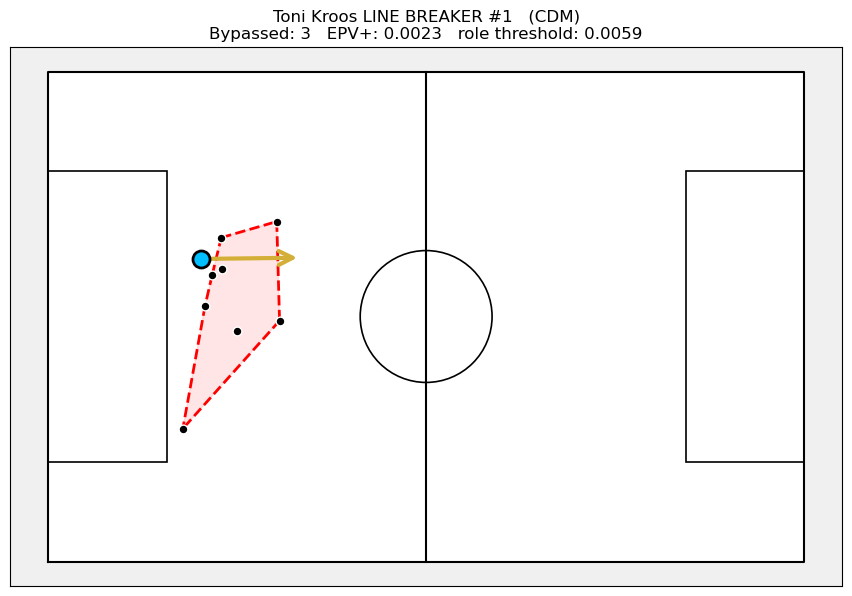

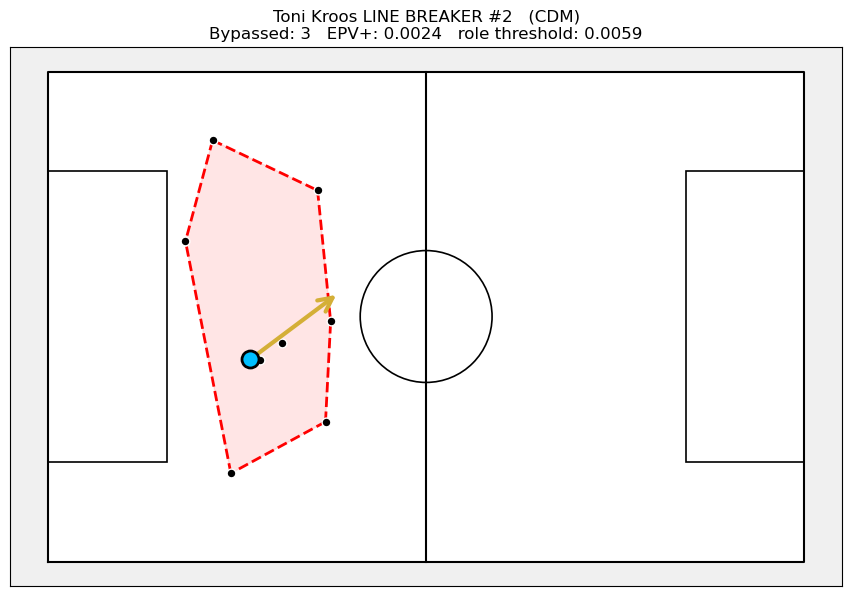

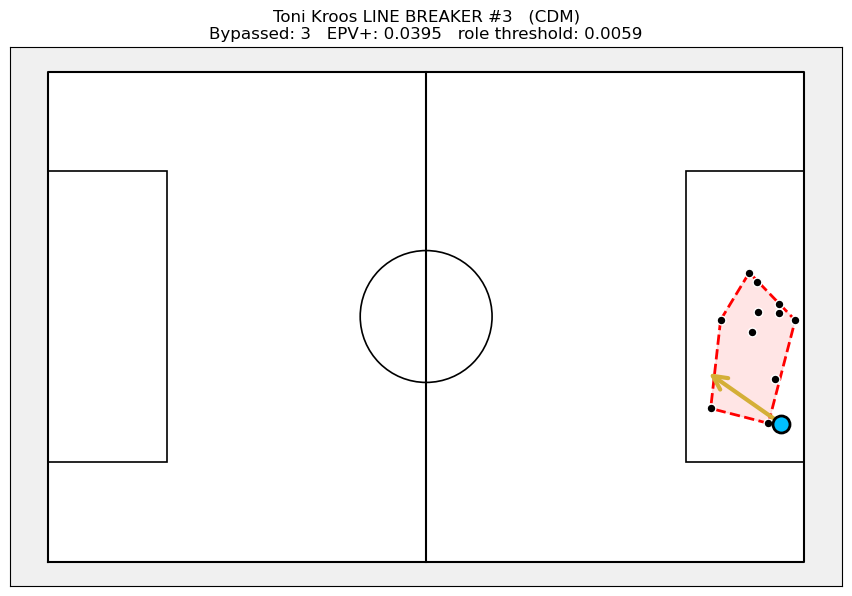

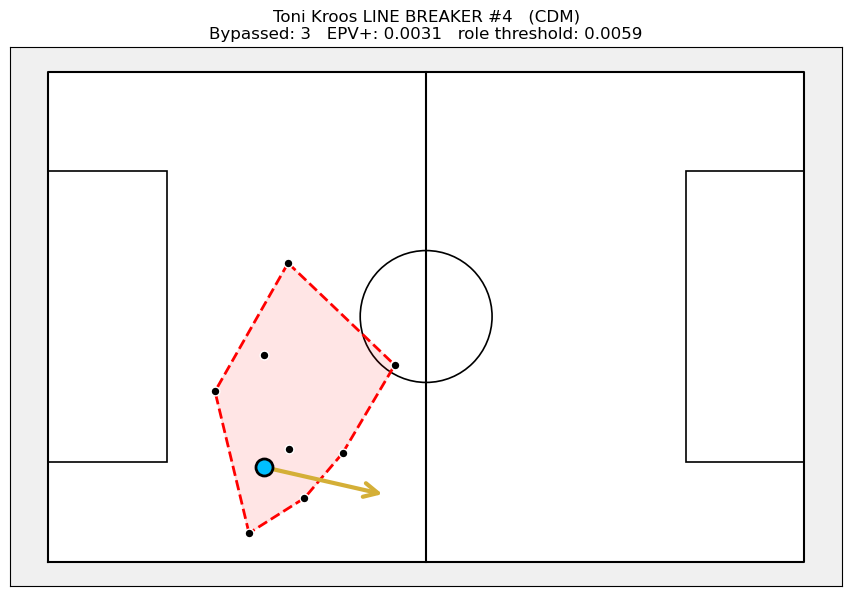

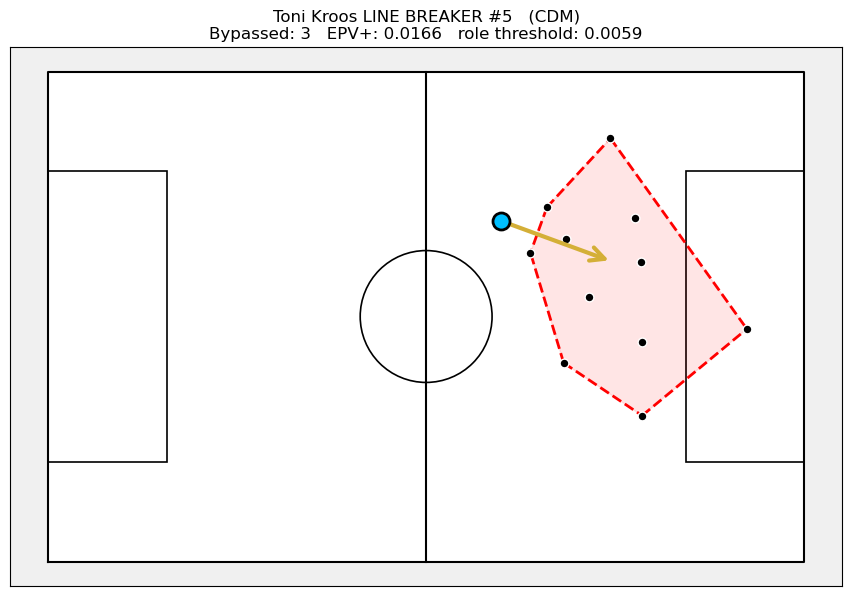

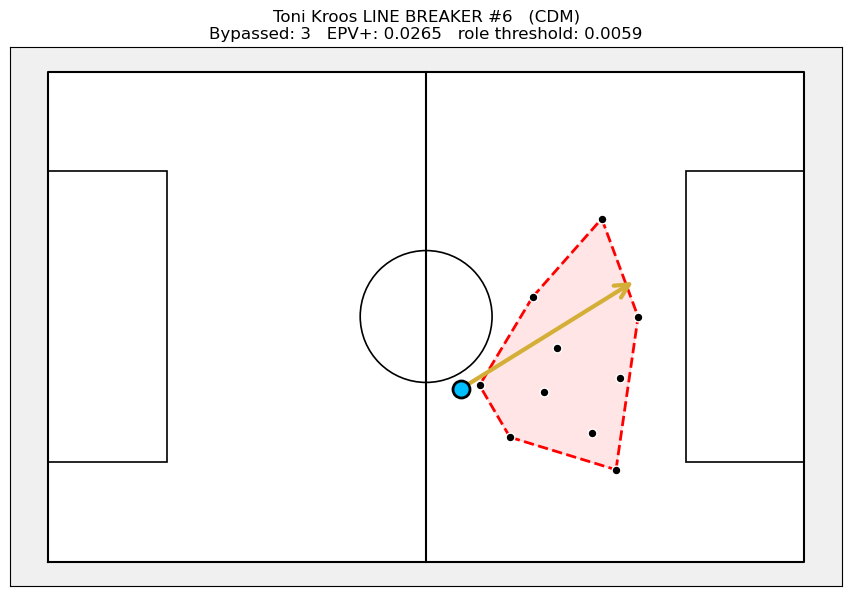

,match_id,event_id,player,team,minute,second,position,hull_area_m2,n_opponents_in_frame,norm_hull_area_m2,...,epv_end,epv_added,geom_type,macro_role,defenders_bypassed,epv_threshold_role,is_line_breaker_epv,is_line_breaker_geom,is_line_breaker_quality,is_line_breaker
0,3942819,8a920161-a913-4ce5-be61-9d6ae7466469,Jordan Pickford,England,0,5,Goalkeeper,673.288721,9,74.809858,...,0.031471,0.022364,Penetration (out->in),GK,2,0.003260,False,False,False,False
1,3942819,401caf44-957b-4c6c-925c-85978734732b,Virgil van Dijk,Netherlands,0,27,Left Center Back,574.481838,10,57.448184,...,0.010750,0.000617,Outside circulation (out->out),CB,0,0.003144,False,False,False,False
2,3942819,01b35a8d-8fff-4545-9cdf-ec2c955f9f3c,Nathan Aké,Netherlands,0,30,Left Back,692.876345,10,69.287634,...,0.008900,-0.001850,Outside circulation (out->out),FB,0,0.006092,False,False,False,False
3,3942819,81fe7d4b-976c-4b0d-b0b2-9b802373f980,Virgil van Dijk,Netherlands,0,32,Left Center Back,798.845816,10,79.884582,...,0.007865,-0.000952,Outside circulation (out->out),CB,0,0.003144,False,False,False,False
4,3942819,4e45ce0f-a07c-47bc-86b0-c090608514da,Stefan de Vrij,Netherlands,0,38,Right Center Back,786.909920,10,78.690992,...,0.010389,0.002188,Penetration (out->in),CB,0,0.003144,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38161,3930158,ce90032e-b224-4e14-9e3e-e51f103eecc0,Leroy Sané,Germany,92,12,Right Wing,221.514328,10,22.151433,...,0.030066,-0.001334,Outside circulation (out->out),W,1,0.014381,False,False,False,False
38162,3930158,cf0e0685-ca6d-4dc3-8381-78e8723ba9d1,İlkay Gündoğan,Germany,92,13,Center Attacking Midfield,242.997309,10,24.299731,...,0.035221,0.004789,Outside circulation (out->out),CAM,1,0.010008,False,False,False,False
38163,3930158,f8611f65-6d7d-400a-b2d8-aa25117f9e56,Jonathan Tah,Germany,92,16,Left Center Back,84.190030,8,10.523754,...,0.039856,0.001356,Outside circulation (out->out),CB,0,0.003144,False,False,False,False
38164,3930158,6e04ffc1-b78f-4f27-b604-2c258b6f3206,Leroy Sané,Germany,92,21,Right Wing,94.286778,8,11.785847,...,0.043772,-0.002275,Outside circulation (out->out),W,3,0.014381,False,True,False,True


In [7]:
from src.line_breaker import main
main()


## Player aggregation

Builds the per-player table `player_space_control_aggregated.csv` by joining:

- **Identity + gravity** from `hull_metrics_aggregated.csv`.
- **Hull rates** computed from `hull_events_lb.csv` (open-play subset).
- **Line-breaker counts** and **EPV statistics**.

### Why hull rates are computed on open play

The percentage metrics (`between_lines_pct`, `hull_exit_pct`, `hull_penetration_pct`, `pressure_resistance_pct`) are interpretable only when their denominator contains comparable passes. Set pieces (corners, free kicks, throw-ins) have degenerate geometry: a corner is taken from outside any hull, and these passes would inflate the denominator without adding matching events to the numerator. Restricting to open play (about 88 % of all passes) gives clean rates.

Gravity is passed through unchanged from the upstream pipeline (its leave-one-out zonal baseline already covers all passes; the bias from including set pieces is small in practice).

### Successful vs. attempted passes — what each metric counts

The aggregation uses a deliberate mix of subsets, and the choice is different by metric family. The intent is documented here so the downstream H1 reading rests on clear foundations.

- **Line-breaker counts and per-90** (`lb_geom`, `lb_epv`, `lb_quality`, and `*_per90`): only **successful passes**. A failed pass is never a line-breaker.
- **Success-rate metrics** (`hull_exit_pct`, `hull_penetration_pct`, `pressure_resistance_pct`): numerator counts successful passes only, denominator counts attempts. These are intentionally success rates, e.g. "of passes received under pressure, how many were completed".
- **between_lines_pct**: counts all open-play passes by the player (successful or failed), it measures how often the player plays the ball while between the lines. Success/failure is not the relevant axis here; the geometric position at the moment of the pass is.
- **EPV-based metrics** (`epv_added_per90`, `epv_penetration_per90`, `epv_inside_circ_per90`, `epv_added_mean`): sum or mean over all open-play passes. Failed passes contribute (typically negative) EPV because the ball ends at an opponent's location. The metric therefore reflects net decision-making impact, and naturally penalises reckless attempts.

**Filter**: players with `minutes_played < 135` (1.5 matches) are dropped at this stage.

**Output**: `player_space_control_aggregated.csv` (272 players).


In [8]:
from src.aggregation import main
main()


LB events: 38,166   Players (hull_agg): 357

 SANITY CHECK  -  open-play rates  vs  all-passes rates
  metric                        mean Δ    median Δ   max |Δ|    corr
  between_lines_pct              -1.19       -1.35     11.00   0.993
  hull_exit_pct                   3.46        1.98     50.00   0.843
  hull_penetration_pct           -0.27        0.00     25.00   0.946
  pressure_resistance_pct        -0.28        0.00     50.00   0.912
------------------------------------------------------------------------------
 Read: small Δ + corr > 0.95 -> recomputation tracks the old rate; the
 set-piece bias is real but moderate, and is now removed from the rates.

Dropped 28 rows (goalkeepers).
Dropped 57 rows (minutes_played < 135).

Saved: /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Space_Control_and_Value/data/player_space_control_aggregated.csv
  272 players × 49 columns

macro_role distribution:
macro_role
MID     65
CB      61
FB      57
WIDE    37
FW      32
CAM     2

,player,team,primary_role,minutes_played,passes_total,passes_analysed,coverage_pct,gravity_hull_pct,gravity_proximity_pct,gravity_composite_pct,...,lb_quality_per90,epv_added_per90,epv_penetration_per90,epv_inside_circ_per90,penetration_per90,inside_circ_per90,between_lines_per90,successful_hull_exits_per90,successful_hull_penetrations_per90,macro_role
0,Declan Rice,England,Left Defensive Midfield,691,536,481,89.738806,2.904906,10.182064,6.543485,...,1.302460,0.214823,0.049159,0.067156,5.991317,3.125904,12.503618,7.684515,5.730825,MID
1,John Stones,England,Right Center Back,686,558,498,89.247312,2.529611,-20.091069,-8.780729,...,0.131195,0.106079,0.020165,-0.000027,7.478134,0.131195,1.443149,1.049563,7.084548,CB
2,Kyle Walker,England,Right Back,690,562,443,78.825623,0.089858,-20.230218,-10.070180,...,1.043478,0.298141,0.109204,0.000028,7.695652,0.260870,1.043478,0.521739,6.260870,FB
3,Toni Kroos,Germany,Left Defensive Midfield,485,545,475,87.155963,-1.007773,-3.949846,-2.478809,...,3.340206,0.391852,0.127523,0.023043,20.041237,3.525773,13.917526,9.463918,19.113402,MID
4,Jude Bellingham,England,Center Attacking Midfield,668,374,331,88.502674,-2.423348,18.366470,7.971561,...,1.347305,0.303798,0.106366,0.084717,4.850299,5.119760,16.571856,10.239521,3.637725,CAM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,Luka Lochoshvili,Georgia,Left Wing Back,166,53,37,69.811321,-10.151388,3.719508,-3.215940,...,0.000000,0.014013,NaN,NaN,NaN,NaN,0.542169,0.542169,0.000000,FB
268,Michael Gregoritsch,Austria,Center Forward,135,32,29,90.625000,-15.196375,28.849639,6.826632,...,0.666667,0.093843,0.056689,0.009171,3.333333,6.000000,14.000000,4.666667,2.000000,FW
269,Mateo Retegui,Italy,Center Forward,162,17,16,94.117647,-12.451235,38.618445,13.083605,...,0.000000,-0.059699,NaN,-0.021090,NaN,3.888889,7.777778,2.222222,0.000000,FW
270,Adam Buksa,Poland,Left Center Forward,153,10,8,80.000000,-8.585846,34.533154,12.973654,...,0.000000,0.006260,NaN,0.004074,NaN,0.588235,1.764706,1.176471,0.000000,FW


## Index design — Space Control

Reduces the 50 columns of `player_space_control_aggregated.csv` to **14 primary mother concepts** (the truly independent metrics) and groups them into **4 composite indices** that are:

- **statistically valid** 
- **footballically coherent** 
- **comparable within-role** 

### Excluded variables

| Variable | Reason |
|---|---|
| `player`, `team`, `primary_role` | Identifiers |
| `minutes_played` | Filter / context, not a skill |
| `passes_total` | Volume of participation |
| `passes_analysed` | All-pass volume, denominator not a feature |
| `passes_op` | Open-play volume, denominator not a feature |
| `coverage_pct` | Data-quality flag |
| `gravity_composite_pct` | Derived = mean(`gravity_hull_pct`, `gravity_proximity_pct`); double-counts. Kept in the CSV as an annotation. |

### The four indices

#### 1. PROGRESSION, *forward play volume*
> "How much, and how well, does this player advance the ball?"

| Axis | Variable |
|---|---|
| LB Geom /90       | `lb_geom_per90` |
| LB Quality /90    | `lb_quality_per90` |
| LB EPV /90        | `lb_epv_per90` |
| Hull Penetr. /90  | `successful_hull_penetrations_per90` |
| Def. Bypassed Avg | `defenders_bypassed_mean` |

`lb_quality` is the **boolean intersection at the event level** (`geom AND epv`), not a mean of two percentages. A player can have many `lb_geom` (bold passes) without much `lb_quality` (those bold passes don't add EPV), a meaningfully distinct signal.

Cronbach's α: 0.72 to 0.82 across roles, AVG ≈ 0.78.

#### 2. DANGEROUSNESS, *threat creation*
> "How much expected threat does this player generate?"

| Axis | Variable |
|---|---|
| EPV Added /90   | `epv_added_per90` |
| EPV Penetr. /90 | `epv_penetration_per90` |
| Circ. EPV /90   | `epv_inside_circ_per90` |

Cronbach's α: 0.39 to 0.70, AVG ≈ 0.51.

Cross-correlation with PROGRESSION ≈ 0.59, expected and acceptable. Players who advance the ball well also tend to create threat, but the indices remain distinct (volume vs. threat).

#### 3. RECEPTION, *between-the-lines play and tight-space technique*
> "How well does this player operate in tight zones with defenders close?"

| Axis | Variable |
|---|---|
| Between Lines % | `between_lines_pct` |
| Hull Exits /90  | `successful_hull_exits_per90` |
| Press. Resist % | `pressure_resistance_pct` |

Cronbach's α: AVG ≈ 0.43.

`pressure_resistance_pct` has small `n` on CB (median 1) and some FW/MID (≤ 5). It is shown next to its own `n` in `player_profile`.

#### 4. GRAVITY, *spatial pull on the defense*
> "How much does this player pull / compact the opposing defense?"

| Axis | Variable |
|---|---|
| Space Attraction % | `gravity_proximity_pct` |
| Gravity Hull %     | `gravity_hull_pct` |
| Def. Pull \|m\|  | `gravity_abs_m` |

Cronbach's α: AVG ≈ -0.07. Strongly negative on CBs because hull and proximity diverge for defenders (a CB can pull the closest defenders in while the overall block stays put). For CBs, read the radar component-by-component rather than relying on the composite.

`gravity_composite_pct` (mean of hull + proximity) stays in the CSV as the original pipeline summary score.

### Pool

Players with fewer than 135 minutes (1.5 matches) are filtered out upstream in `player_space_control_aggregated.csv`. 

- Pool: 272 players.
- By role: CAM 20 / CB 61 / FB 57 / FW 32 / MID 65 / WIDE 37.

### Four prototype views

- **`player_profile(name)`**, 4-panel radar of the four indices.
- **`head_to_head(p1, p2)`**, overlaid radar, ideally same role.
- **`role_leaderboard(role, theme)`**, top-N within role.
- **`role_archetypes(role, x_theme, y_theme)`**, 2D scatter for cluster discovery.



In [9]:
from src.indices   import load_player_table, build_pct_table
from src.dashboard import player_profile, head_to_head, role_leaderboard, role_archetypes

# Load the player table once and build the within-role percentile matrix.
df = load_player_table()
df, pct = build_pct_table(df)

# Demo of the four prototype views.
player_profile("Rodri", df, pct)
head_to_head("Rodri", "Tchouam", df, pct)
role_leaderboard("MID", "DANGEROUSNESS", df, pct, top_n=15)
role_archetypes("MID", x_theme="PROGRESSION", y_theme="DANGEROUSNESS",
                df=df, pct=pct)


  Rodrigo Hernández Cascante  -  Spain
  Role: Right Defensive Midfield (MID)   Minutes: 532
  Quality: ok
--------------------------------------------------------------------------------------
  PROGRESSION     60.9/100       DANGEROUSNESS   47.2/100
  RECEPTION       75.7/100       GRAVITY         59.5/100 ↑
  pressure-resist (annot)      76.5%  on n=17
  gravity_composite (derived)  +9.0%  [mean of hull+proximity, off-radar]
--------------------------------------------------------------------------------------
  TOP STRENGTHS (percentile within MID):
    + Hull Exits /90 [RECE]              95.4
    + Between Lines % [RECE]             80.0
    + Space Attraction % [GRAV]          76.9
  TOP WEAKNESSES:
    - Def. Bypassed Avg [PROG]           49.2
    - Gravity Hull % [GRAV]              49.2
    - EPV Added /90 [DANG]               35.4
--------------------------------------------------------------------------------------
  MOST SIMILAR (within MID):
    ~ Kobbie Mainoo           

  HEAD-TO-HEAD:  Rodrigo Hernández Cascante  vs  Aurélien Djani Tchouaméni
                 Spain                      France
                 MID · 532m         MID · 476m
--------------------------------------------------------------------------------------
  Index           Rodrigo Hernández Ca     Aurélien Djani Tchou    Winner
  PROGRESSION                     60.9                     73.2    Aurélien Djani Tch (+12.3)
  DANGEROUSNESS                   47.2                     65.6    Aurélien Djani Tch (+18.5)
  RECEPTION                       75.7                     28.5    Rodrigo Hernández  (+47.2)
  GRAVITY                         59.5                     20.0    Rodrigo Hernández  (+39.5)


## Construct validity check

For each composite index this cell prints:

- **Cronbach's α** by macro-role (target ≥ 0.6 for a tight construct, ≥ 0.4 acceptable for multi-faceted ones).
- **Cross-correlation** between the four indices (target |r| < 0.6, composites should not be redundant).


In [10]:
from src.validation import construct_validity
construct_validity(pct)


  CONSTRUCT VALIDITY  -  Cronbach's α per index and role
  Index               CB      FB     MID     CAM    WIDE      FW     AVG
  PROGRESSION       0.78    0.81    0.84    0.67    0.77    0.76    0.77
  DANGEROUSNESS     0.47    0.49    0.66    0.46    0.62    0.54    0.54
  RECEPTION         0.88    0.34    0.11    0.73    0.66   -0.24    0.41
  GRAVITY          -0.98   -0.10    0.40   -0.09    0.42    0.17   -0.03

  CROSS-CORRELATION BETWEEN INDICES  (target: |r| < 0.6)

  ALL ROLES:
                   PROGRESSION_idx  DANGEROUSNESS_idx  RECEPTION_idx  GRAVITY_idx
PROGRESSION_idx               1.00               0.56           0.06        -0.15
DANGEROUSNESS_idx             0.56               1.00           0.01        -0.17
RECEPTION_idx                 0.06               0.01           1.00         0.16
GRAVITY_idx                  -0.15              -0.17           0.16         1.00

  MID:
                   PROGRESSION_idx  DANGEROUSNESS_idx  RECEPTION_idx  GRAVITY_idx
PROGRE

## Export indices CSV

Persists `player_space_control_indices.csv`, a table:

- **Identity**: player, team, primary_role, macro_role, minutes_played, coverage_pct, pressure_resistance_n.
- **Annotations**: `gravity_composite_pct` (derived summary) and `gravity_directional_m` (signed pull).
- **4 composite indices** as `idx__<THEME>` (within-role percentile averages).
- **14 within-role percentiles** as `pct__<mother_variable>` (one per radar axis).

Raw mother values live in `player_space_control_aggregated.csv`.

Rows are sorted by `macro_role` and then by the mean of the four indices, descending.


In [11]:
from src.validation import export_indices_csv
export_indices_csv(df, pct)


✔ Saved /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Space_Control_and_Value/data/player_space_control_indices.csv  -  272 rows × 27 columns
  Identity: 9   Indices: 4   Percentiles: 14


,player,team,primary_role,macro_role,minutes_played,coverage_pct,pressure_resistance_n,gravity_composite_pct,gravity_directional_m,idx__PROGRESSION,...,pct__defenders_bypassed_mean,pct__epv_added_per90,pct__epv_penetration_per90,pct__epv_inside_circ_per90,pct__between_lines_pct,pct__successful_hull_exits_per90,pct__pressure_resistance_pct,pct__gravity_proximity_pct,pct__gravity_hull_pct,pct__gravity_abs_m
150,Pedro González López,Spain,Center Attacking Midfield,CAM,185,94.565217,10,7.903222,4.379802,80.00,...,70.00,35.00,65.00,100.00,100.00,100.00,92.50,95.00,10.00,75.00
105,Christoph Baumgartner,Austria,Center Attacking Midfield,CAM,301,90.740741,10,10.479439,5.187695,49.00,...,85.00,85.00,70.00,90.00,90.00,50.00,80.00,80.00,60.00,95.00
59,Daniel Olmo Carvajal,Spain,Center Attacking Midfield,CAM,432,92.432432,13,5.792314,3.179582,61.00,...,75.00,75.00,80.00,65.00,75.00,90.00,40.00,70.00,25.00,50.00
140,Georgiy Sudakov,Ukraine,Center Attacking Midfield,CAM,262,92.436975,5,9.802526,3.265894,67.00,...,45.00,40.00,55.00,80.00,40.00,60.00,65.00,75.00,70.00,55.00
58,Kevin De Bruyne,Belgium,Center Attacking Midfield,CAM,375,91.228070,9,9.021732,2.741696,80.00,...,65.00,70.00,35.00,75.00,35.00,80.00,45.00,40.00,90.00,30.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,Rafael Alexandre Conceição Leão,Portugal,Left Wing,WIDE,281,80.530973,5,-0.084984,0.941197,67.57,...,81.08,91.89,91.89,24.32,8.11,16.22,8.33,16.22,16.22,8.11
196,Dennis Man,Romania,Right Midfield,WIDE,271,87.500000,4,0.337159,1.264980,59.46,...,97.30,83.78,64.86,29.73,10.81,8.11,4.17,5.41,24.32,16.22
257,Ferrán Torres García,Spain,Right Wing,WIDE,148,86.666667,0,0.705505,1.478383,32.16,...,52.70,86.49,2.70,5.41,35.14,29.73,NaN,2.70,94.59,18.92
175,Ivan Schranz,Slovakia,Right Wing,WIDE,325,86.666667,2,2.351551,3.020340,37.03,...,52.70,13.51,24.32,10.81,29.73,21.62,23.61,81.08,2.70,72.97


## H1 validation — contextual vs naive rankings

The implicit claim of **Hypothesis 1** is that contextual spatial metrics surface players that **naive aggregate stats miss**. This cell tests that claim head-on, and does so in two registers: a four-row quantitative summary and a four-panel scatter.

### The numerical claim

For each composite index paired with its single best naive proxy, the cell prints:

- **Spearman ρ** between the within-role naive percentile and the contextual index. Values close to 1 mean the contextual ranking only reshuffles the edges of the naive view; values closer to 0 mean it substantively re-orders the leaderboard.
- **mean |Δ|**, the average absolute rank shift in percentile points (Δ = ctx − naive). Read it as: "the typical player moves N percentile points between the two views".
- **% |Δ| > 20**, the share of the pool whose ranking shifts by more than 20 percentile points. These are the **scouting-relevant disagreements**, players who would be systematically miscalled by a naive-only workflow.

### The visual claim

The four scatter panels are built on a strictly identical frame:

- **X axis**, within-role percentile of the *naive* metric (raw volume or raw rate, the kind that already lives in any standard data feed).
- **Y axis**, within-role percentile of the *contextual* counterpart (an index or rate that adds opponent geometry, EPV, or both).
- **Off-diagonal points**, the substantive value-add of the contextual approach. Above the diagonal: underrated by naive, lifted by context. Below: the opposite.

Each scatter targets a different axis of the H1 thesis:

1. **Pass volume vs PROGRESSION**. Does the PROGRESSION index just rank players by how many passes they play? If the cloud collapsed onto the diagonal, the index would be a re-skinned volume count. The vertical spread (high `passes /90` but middling PROGRESSION, or the opposite) is the proof that volume alone misses *what kind* of passing is being done.
2. **Raw line-breakers vs Quality line-breakers**. Does layering the EPV criterion on top of the geometric line-break change who is on top? A player can split three opponents with a square pass that does not advance the ball, and the EPV filter strips those out. Off-diagonal points are passers whose line-breaks are *bold but cheap*, or *valuable*.
3. **Penetration count vs EPV-weighted penetration**. Do the most frequent hull penetrators also produce the most valuable ones? Two players with the same penetration count can carry very different threat weights depending on where on the pitch the penetrations land.
4. **Total EPV vs DANGEROUSNESS index**. Does the DANGEROUSNESS composite actually disagree with the single best EPV metric? If they collapsed onto the diagonal, the composite would be redundant. The spread shows that decomposing threat into EPV-added, EPV-on-penetration and EPV-inside-circulation reorders the leaderboard meaningfully.

Color encodes macro-role, so the reader can visually verify that the disagreements are not concentrated in a single role.

### The console tables

After the figure, the cell prints a **head-to-head** between the top-15 by naive `passes /90` and the top-15 by `idx__PROGRESSION` for **MID** specifically. Players are flagged with whether they appear in the other list. Then a **per-role overlap summary** repeats the same exercise for every macro-role (CB / FB / MID / CAM / WIDE / FW), so the reader can judge in one glance how much the two rankings disagree across the full pool.


In [12]:
from src.validation import naive_vs_contextual
naive_vs_contextual(df, pct)


  H1 QUANTITATIVE SUMMARY  -  contextual vs naive ranking, within macro-role
        Index         Naive proxy   n  Spearman ρ  mean |Δ|  % |Δ|>20
  PROGRESSION          passes /90 272       0.465      21.7      47.1
DANGEROUSNESS total EPV added /90 272       0.839      12.7      21.0
    RECEPTION     between-lines % 272       0.748      14.9      29.4
      GRAVITY gravity proximity % 272       0.599      18.5      39.3
--------------------------------------------------------------------------------------
  rho close to 1   = contextual reshuffles only the edges of the naive ranking
  rho closer to 0  = the contextual view substantively re-orders the leaderboard
  mean |Δ|         = average rank shift, percentile points
  % |Δ|>20          = share of players whose ranking moves > 20 pp -
                     these are the scouting-relevant disagreements


  Top-15 MID:  naive (passes /90)  vs  contextual (PROGRESSION idx)
  Overlap         : 10/15
  Only in naive   :  5 - ['Bryan Cristante', 'Joey Veerman', 'Marcelo Brozović', 'Morten Hjulmand', 'Rodrigo Hernández Cascante']
  Only contextual :  5 - ['Fabián Ruiz Peña', 'Mateo Kovačić', 'Robert Andrich', 'Trent Alexander-Arnold', 'Youri Tielemans']
--------------------------------------------------------------------------------------

  TOP-15 BY NAIVE  (passes /90)

                       player        team  passes_per90  PROGRESSION_idx  also_in_ctx
                   Toni Kroos     Germany         101.1             92.9         True
      Jorge Luiz Frello Filho       Italy          98.6             68.3         True
                  Luka Modrić     Croatia          84.4             93.8         True
       Vitor Machado Ferreira    Portugal          83.1             80.9         True
              Morten Hjulmand     Denmark          79.3             45.2        False
           Fl

## H1 validation — scouting discoveries

The previous cell showed that contextual and naive rankings disagree. This one answers **who specifically does the contextual approach surface that naive stats miss**.

For each composite index we pair it with its single best naive proxy and compute, for every player, the within-role rank shift `Δ = ctx_index_pct − naive_pct`.

| Composite index | Naive proxy |
|---|---|
| PROGRESSION   | passes /90 (volume) |
| DANGEROUSNESS | total EPV added /90 (single threat metric) |
| RECEPTION     | between-lines % alone |
| GRAVITY       | gravity proximity % alone |

Two views follow:

1. **Discoveries**, top 12 players per index with the largest **positive** Δ (the H1 scouting nuggets: undervalued by naive stats, lifted by the contextual index).
2. **Naive overrating**, top 12 with the largest **negative** Δ (players whose naive ranking is inflated by team context but whose contextual contribution is lower).

A console table at the bottom lists the per-role top 3 discoveries for each index.

### Case studies — three named discoveries

**Bendegúz Bolla, Hungary, FB.** PROGRESSION_idx ≈ 73 vs `passes /90` percentile ≈ 7. The textbook H1 case. A full-back in a low-possession national side ranks in the bottom decile by raw passing volume, yet finishes in the top quartile of full-backs on PROGRESSION. The reason is visible in the line-breaker pipeline: when Bolla does pass, he produces clean line-breakers at a per-90 rate competitive with full-backs from far stronger teams. A naive volume-only filter would never put him in a scouting shortlist; the contextual index does. The next cells visualise his quality line-breakers directly.

**Tomáš Souček, Czech Republic, MID.** PROGRESSION_idx ≈ 63 vs `passes /90` percentile ≈ 3. Souček is publicly framed as a defensive, aerial-duel midfielder, and the naive view confirms it. 3rd percentile in passing volume across midfielders is bottom-of-the-pool. The contextual lens flips the angle: when he plays, he plays *forward*, with hull penetrations and quality line-breakers per 90 well above the role median. The H1 reading: the PROGRESSION index is not measuring how often a midfielder touches the ball, it is measuring what they do with the ball when they do touch it.

**Arda Güler, Turkey, FW.** RECEPTION_idx ≈ 64 vs `between_lines %` percentile ≈ 3. The most informative case in the pool, because it shows the gap between a single proxy and a multi-axis composite. Güler's between-lines rate alone places him in the bottom 3 % of forwards: he simply does not receive the ball between the lines very often in Turkey's setup. But the other two RECEPTION axes tell a very different story. His successful hull-exits per 90 are at the 97th percentile, and his pressure-resistance rate sits at the 91st (8 events, all completed). The composite reads this correctly as "when Güler does end up in tight space, he wins", and lifts his RECEPTION index into the upper half of forwards. A naive single-metric filter would discard him before any analyst opened his radar; the multi-axis composite does not.

The pattern across the three cases is the same. Each player has a low naive percentile (3 to 7) and a mid-to-high contextual index (63 to 73) inside their macro-role. 


In [13]:
from src.validation import scouting_discoveries
scouting_discoveries(df, pct)


  PER-ROLE TOP 3 DISCOVERIES BY INDEX  (largest positive Δ percentile)

  PROGRESSION  (naive proxy: passes /90)
  --------------------------------------------------------------------------------------
  CB    : Tomáš Holeš (+52), Lasha Dvali (+49), Ricardo Iván Rodríguez Araya (+49)
  FB    : Bendegúz Bolla (+66), Anthony Ralston (+50), Przemysław Frankowski (+44)
  MID   : Tomáš Souček (+60), Nicolae Claudiu Stanciu (+40), Timi Elšnik (+37)
  CAM   : Roland Sallai (+39), John McGinn (+29), Dušan Vlahović (+25)
  WIDE  : Cody Mathès Gakpo (+57), Jasir Asani (+46), Dennis Man (+38)
  FW    : Che Adams (+59), Breel-Donald Embolo (+55), Harry Kane (+46)

  DANGEROUSNESS  (naive proxy: total EPV added /90)
  --------------------------------------------------------------------------------------
  CB    : William Saliba (+33), Philipp Lienhart (+30), Andreas Christensen (+30)
  FB    : Dan Ndoye (+36), Luke Shaw (+32), Mert Müldür (+30)
  MID   : Lukáš Provod (+28), João Maria Lobo Alves Pa

## H1 visual proof — what a "line breaker" looks like

The H1 thesis hinges on a precise event-level definition. A **quality line-breaker** is a successful open-play pass that simultaneously bypasses at least 3 opponents inside a 5 m corridor along the pass line, and adds EPV above the role-specific 75th percentile. The two halves of the definition target different things: the geometric half rules out short circulation, the EPV half rules out bold-but-cheap passes.

This cell loads `hull_events_lb.csv` and the cached 360 freeze frames (`opp_positions_cache.parquet`) and replays Bendegúz Bolla's quality line-breakers, the same player highlighted as a top-5 PROGRESSION discovery in the previous case-study block. Each panel draws:

- the **opponent convex hull** at the moment of the pass (red dashed polygon, light fill).
- the **passer's location** (cyan dot) and the **pass vector** (gold arrow).
- every **opponent in the frame** (black dot).
- a **header** with the role-specific EPV threshold, the actual EPV added, and the count of defenders bypassed inside the 5 m corridor.

The intent is to show on a real Euro 2024 example that the line-breaker definition is doing what it claims, and to give the H1 numerical evidence a footballically inspectable footprint. Swap `"Bendegúz Bolla"` for any other player and rerun to visually audit other cases.


Plotting 4 'quality' line-breaker(s) for Bendegúz Bolla  (Hungary)  role=FB


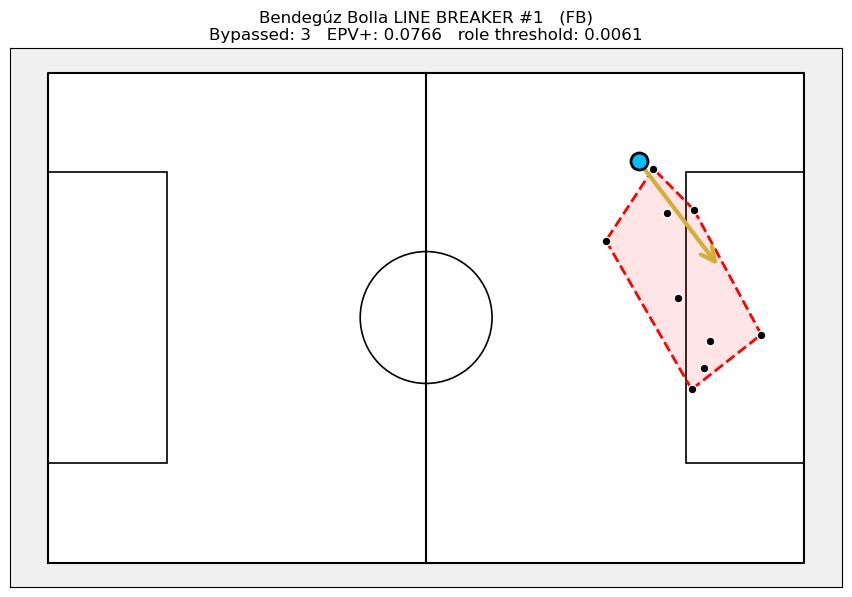

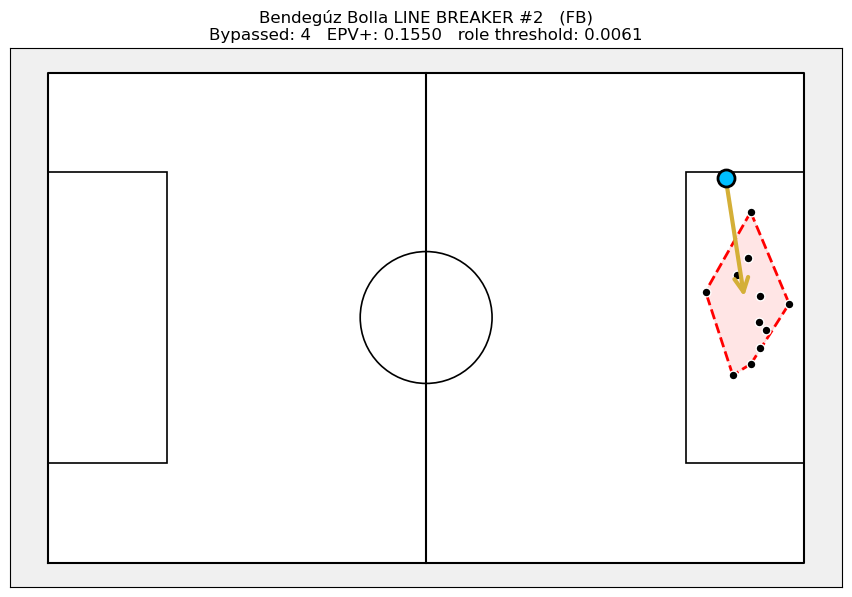

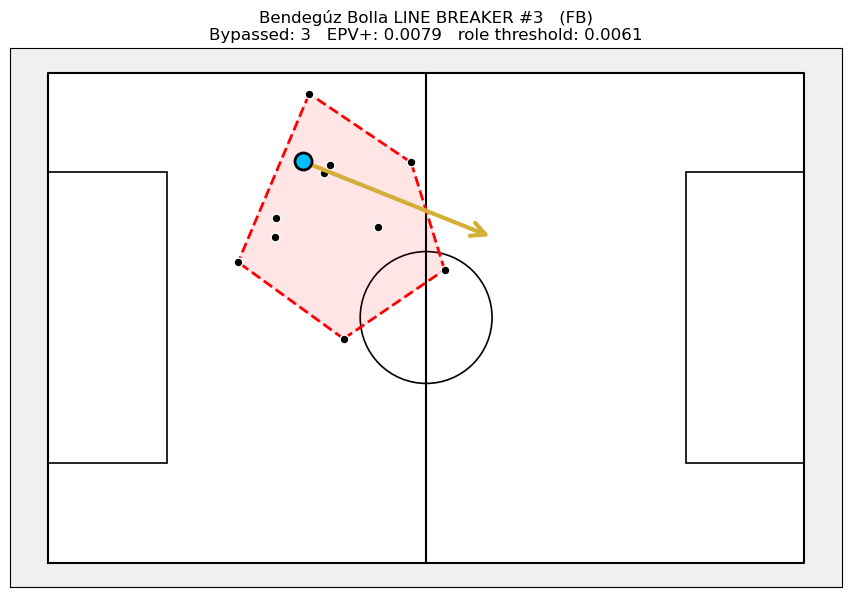

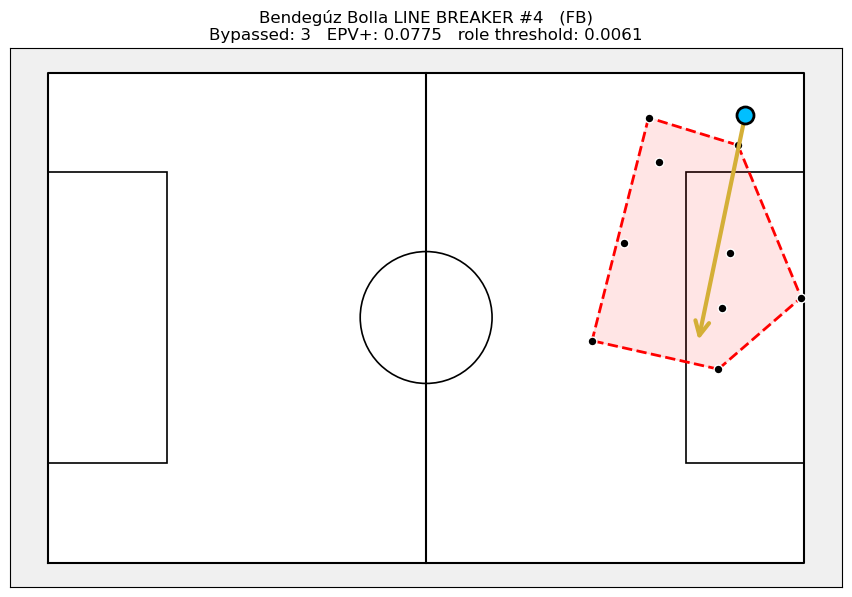

In [14]:
from src.line_breaker import show_line_breakers

# Bendegúz Bolla - PROGRESSION top-5 discovery: low naive volume,
# high contextual rank because the few passes he plays are clean line-breakers.
show_line_breakers("Bendegúz Bolla", n=4, kind="quality")


## Where the `NaN`s come from

| Column family | Structural cause | Why it is concentrated where it is |
|---|---|---|
| `pressure_resistance_pct` | `pressure_resistance_n == 0`, the player never received a pass under the strict pressure rule (≥ 2 opponents within 2.5 m of the receiver) | Defenders (CB / FB) and deep midfielders rarely receive in true pressure cones; their natural ball reception is in space |
| `epv_inside_circ_*`, `inside_circ_n` | the player never made a pass that started **and** ended inside the opponent hull | Centre-backs and full-backs play almost all passes from outside the block; inside-circulation is by construction a midfield/attacking action |
| `epv_penetration_*`, `penetration_n` | the player never made a hull-penetration pass (start outside the block, end inside it) | Forwards mostly *receive* in the final third rather than penetrating into it; some full-backs in low-block teams equally never get into the penetrate-from-outside posture |
| `hull_exit_pct` | `hull_exit_n == 0`, the player never started a pass from inside the hull | Two CBs (Demiral, Fiola) who, in their tournament minutes, were never inside an opponent hull as the passer |


In [15]:
import pandas as pd
from src import config

agg = pd.read_csv(config.PLAYER_AGG_PATH)

print("=" * 76)
print(f"  player_space_control_aggregated.csv  -  {agg.shape[0]} rows  x  {agg.shape[1]} cols")
print("=" * 76)

na_counts = agg.isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)
print(f"\n  Total rows with at least one NaN: {agg.isna().any(axis=1).sum()}/{len(agg)}")
print(f"  Columns with NaNs                : {len(na_counts)}/{agg.shape[1]}")
print(f"\n  NaN count per column:")
for col, n in na_counts.items():
    print(f"    {col:<30s} {n:>4d}")

# Players with the most NaN entries (curiosity / diagnostic).
print("\n" + "=" * 76)
print("  PLAYERS WITH THE MOST NaN ENTRIES  (top 8)")
print("=" * 76)
agg["_n_na"] = agg.isna().sum(axis=1)
top = (agg.nlargest(8, "_n_na")
          [["player", "team", "macro_role", "minutes_played", "_n_na"]])
print(top.to_string(index=False))
print("\n  -> These are mostly defenders with 1-2 matches played: small-sample"
      "\n     gaps in passes that simply did not happen, not data corruption.")


  player_space_control_aggregated.csv  -  272 rows  x  49 cols

  Total rows with at least one NaN: 54/272
  Columns with NaNs                : 12/49

  NaN count per column:
    pressure_resistance_pct          46
    epv_inside_circ_mean             11
    epv_inside_circ_sum              11
    inside_circ_n                    11
    epv_inside_circ_per90            11
    inside_circ_per90                11
    epv_penetration_mean              3
    epv_penetration_sum               3
    penetration_n                     3
    epv_penetration_per90             3
    penetration_per90                 3
    hull_exit_pct                     2

  PLAYERS WITH THE MOST NaN ENTRIES  (top 8)
              player    team macro_role  minutes_played  _n_na
    Luka Lochoshvili Georgia         FB             166     10
       Merih Demiral  Turkey         CB             216      7
       Arthur Theate Belgium         FB             255      6
     Marin Pongracic Croatia         CB        